In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
memory = InMemorySaver()
config = {"configurable": {"thread_id": "2"}}

In [3]:
# Define the state structure.
# Using Annotated with operator.add enables appending string lists together.
class State(TypedDict):
    nlist : Annotated[list[str], operator.add]

In [4]:
# Node A dynamically routes next steps based on user input.
# It uses the `interrupt()` helper function to pause graph execution and prompt
# for human interaction (admin review/input) when an unexpected input value is encountered.
def node_a(state: State) -> Command[Literal["b", "c","d", END]]:
    print("Entered 'a' node")
    select = state["nlist"][-1]
    if select == "b":
        goto = "b"
    elif select == "c":
        goto = "c"
    elif select == "d":
        goto = "d"
    else:
        # Pause execution using LangGraph interrupt.
        # This raises an interrupt exception up to the caller and exposes the value.
        # The execution resumes from this exact line once the user feeds a response via a resume Command.
        admin = interrupt(f"Unexpected input '{select}'")
        print(admin)
        if admin == "continue":
            goto = "b"
        else:
            goto = END
            select = "q"
            
    return Command(
        update = State(nlist = [select]),
        goto = [goto]
    )


# Standard nodes that update state variables and automatically move next
def node_b (state: State) -> State:
    return(State(nlist = ["B"]))

def node_c (state: State) -> State:
    return(State(nlist = ["C"]))

def node_d(state: State) -> State:
    return(State(nlist = ["D"]))

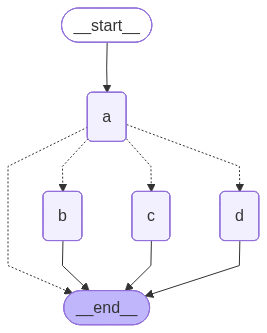

In [5]:
# Compile the graph builder with the checkpointer to persist thread history and catch interrupts
builder = StateGraph(State)

builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("d", node_d)

builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
builder.add_edge("d", END)

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
while True:
    user = input('b, c, d,or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config)
    print(result)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)
        human = input(f"\n{msg}: ")

        human_response = Command(
            resume = human
        )
        result = graph.invoke(human_response, config)
        
    if result['nlist'][-1] == "q":
        print("quit")
        break


Entered 'a' node
{'nlist': ['b', 'b', 'B']}
Entered 'a' node
{'nlist': ['b', 'b', 'B', 'c', 'c', 'C']}
Entered 'a' node
{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'f'], '__interrupt__': [Interrupt(value="Unexpected input 'f'", id='dc8e59894e3a9bcbf9252e79ad448f14')]}
Interrupt:{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'f'], '__interrupt__': [Interrupt(value="Unexpected input 'f'", id='dc8e59894e3a9bcbf9252e79ad448f14')]}
Unexpected input 'f'
Entered 'a' node
continue
Entered 'a' node
{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'f', 'f', 'B', 'a'], '__interrupt__': [Interrupt(value="Unexpected input 'a'", id='1cbf4c4eac0fa8c39bf8b6a0422ba645')]}
Interrupt:{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'f', 'f', 'B', 'a'], '__interrupt__': [Interrupt(value="Unexpected input 'a'", id='1cbf4c4eac0fa8c39bf8b6a0422ba645')]}
Unexpected input 'a'
Entered 'a' node
q
quit
